1. Missing Values:
 Count Contraction        0
lenght of contraction    0
STD                      0
Entropy                  0
Contraction times        0
Pre-term                 0
dtype: int64


C:\Users\husan\anaconda3\Lib\site-packages\sklearn\utils\validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


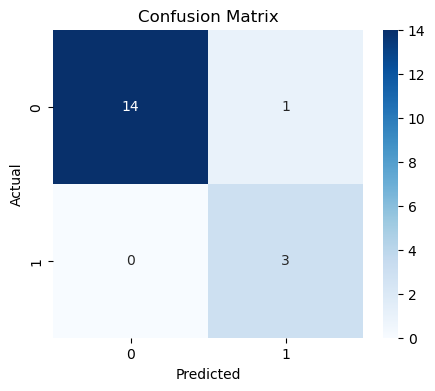

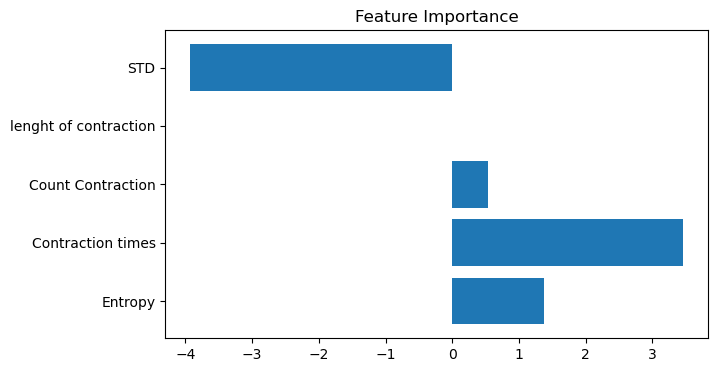


2.Model Accuracy : 0.9444444444444444

3.Confusion Matrix:

[[14  1]
 [ 0  3]]

4.Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.93      0.97        15
           1       0.75      1.00      0.86         3

    accuracy                           0.94        18
   macro avg       0.88      0.97      0.91        18
weighted avg       0.96      0.94      0.95        18



In [3]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = pd.read_csv(r"C:\Users\husan\Downloads\preterm birth dataset .csv")

#Check missing values
print("1. Missing Values:\n",data.isnull().sum())

#Feature scaling
columns = ['Count Contraction', 'lenght of contraction', 'STD']
scaler = MinMaxScaler()
data[columns] = scaler.fit_transform(data[columns])

#Select input and output features
Xcolumns = ['Entropy', 'Contraction times', 'Count Contraction',
       'lenght of contraction', 'STD']
Ycolumns = ['Pre-term']
X = data[Xcolumns]
Y = data[Ycolumns]


X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.3,random_state=1) 
model = LogisticRegression(penalty="l1",C=3,solver="liblinear")
model.fit(X_train,Y_train)
Y_pred = model.predict(X_test)

cm = confusion_matrix(Y_test, Y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")
plt.show()

importance = model.coef_[0]
feature_importance = pd.DataFrame({
    'Feature':Xcolumns,
    'Importance':importance
})

plt.figure(figsize=(7,4))
plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)
plt.title("Feature Importance")
plt.savefig(
    "feature_importance.png"
)
plt.show()

accuracy = accuracy_score(Y_test, Y_pred)
print("\n2.Model Accuracy :", accuracy)

print("\n3.Confusion Matrix:\n")
print(confusion_matrix(Y_test, Y_pred))

print("\n4.Classification Report:\n")
print(classification_report(Y_test, Y_pred))